# 04 — Model 1: gas recommendation (NG flow + air-fuel ratio)

**What the operator gets.** One recommendation per 20-min reversal cycle, ready by minute 15 so it can be set in the minute 15–20 window. It contains:
- **NG flow**, in the same unit as the workbook column `dcs_60_MelterGasflowvalue…` (no conversion, per plant). One value for both inlets (common header).
- **Air-fuel ratio**, and the matching secondary air flow.

**Inputs**
| Input | Source | Frequency |
|---|---|---|
| NCV | automatic (UEMS) | every 15 min, latest value |
| Draw, cullet % | operator | daily |
| Optical crown temperature | operator | current reading |
| Barrier + melter boost | **read from the DB** (plant decision: gas runs every 15 min, boost is recommended hourly) | last hour |

**Method**
1. **Daily gas-heat target.** A quantile regression `gas_Gcal ~ draw + barrier_Gcal + melter_Gcal` is refitted every day on the **last 45 usable days**, at the **25th percentile**. That is the heat the most efficient quarter of comparable recent days needed. A rolling refit follows furnace ageing automatically (ageing ≈ +0.19%/month, nb03).
2. **Steady heat over the day,** with a small optical trim (the same strength operators use today).
3. **NG = heat per 15 min ÷ latest NCV.** This is exact NCV compensation (operators make ~70% of the needed correction after one hour, nb03).
4. **AFR = air-per-Mcal target × NCV / 1000.** The target is the historical P25 (inside the proven range; no O₂ analyser).
5. **Limits** = historical P1–P99 (plant: use historical limits for now). Back-tested both with and without them.

**Back-test:** Jun–Aug 2026, walk-forward (each day only sees earlier days). Sep 2026 is the validation month once its draw arrives (§8).

In [1]:
import sys; sys.path.insert(0, '../src')
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import data_prep as dp
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 40)
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, INK2, MUTED, GRID, SURF = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#fcfcfb'
plt.rcParams.update({'figure.facecolor': SURF, 'axes.facecolor': SURF, 'axes.edgecolor': MUTED,
    'axes.labelcolor': INK2, 'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.grid': True,
    'grid.color': GRID, 'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'lines.linewidth': 1.6, 'font.size': 10, 'axes.titlesize': 11, 'axes.titlecolor': INK,
    'legend.frameon': False, 'figure.dpi': 110})
import recommender as rc
q = pd.read_parquet('../data/processed/ar_15min_clean.parquet')
h = pd.read_parquet('../data/processed/hourly_clean.parquet')
d = pd.read_parquet('../data/processed/daily_clean.parquet')
u = rc.add_gcal_columns(d[d.usable])
u['E_g'] = u.energy_kcal / 1e6
TEST_START, TEST_END = '2026-06-01', '2026-08-31'
test_days = u[(u.index >= TEST_START) & (u.index <= TEST_END)].index
print('usable days:', len(u), '| test days (Jun-Aug 2026):', len(test_days))

usable days: 316 | test days (Jun-Aug 2026): 85


## 1. Historical limits (P1–P99 of normal operation)

In [2]:
lim = rc.historical_limits(q, h)
LIMITS = {'ng_scm': tuple(lim.loc['ng_scm (per 15 min)', ['P1', 'P99']]), 'afr': tuple(lim.loc['afr', ['P1', 'P99']])}
lim.round(2)

,P1,median,P99
ng_scm (per 15 min),73.86,82.54,96.34
afr,10.99,12.17,13.44
air_per_mcal,1.20,1.27,1.34
bb_kwh (per hour),114.30,379.60,609.80
opt_temp (°C),1570.00,1575.00,1578.00
mb3_temp (°C),1316.14,1320.24,1325.56
crown_tc (°C),1559.17,1567.01,1573.75


## 2. Choosing the frontier: which quantile and which window?
A good frontier model must be **calibrated out of sample**: on test days, the share of days that actually used *less* gas than the target should equal τ. If it's much lower, the target is unrealistically low (it extrapolates). If it's much higher, it's too loose.

In [3]:
grid = []
for W in [30, 45, 60]:
    for tau in [0.5, 0.35, 0.25, 0.2]:
        t = rc.walk_forward_gas_targets(u, test_days, tau=tau, window=W)
        te = u.loc[test_days]
        grid.append(dict(window_days=W, tau=tau, share_below_target=(te.gas_g <= t).mean(),
                         calib_error=abs((te.gas_g <= t).mean() - tau),
                         energy_saving_pct=100 * (te.gas_g - t).sum() / te.E_g.sum(),
                         mae_Gcal=(te.gas_g - t).abs().mean()))
grid = pd.DataFrame(grid)
grid.round(3).sort_values(['window_days', 'tau'])

,window_days,tau,share_below_target,calib_error,energy_saving_pct,mae_Gcal
3,30,0.20,0.188,0.012,0.869,1.264
2,30,0.25,0.224,0.026,0.702,1.120
1,30,0.35,0.271,0.079,0.453,0.988
0,30,0.50,0.329,0.171,0.220,0.904
7,45,0.20,0.200,0.000,0.911,1.255
6,45,0.25,0.247,0.003,0.767,1.199
5,45,0.35,0.294,0.056,0.561,1.100
4,45,0.50,0.388,0.112,0.219,1.022
11,60,0.20,0.094,0.106,1.397,1.527
10,60,0.25,0.106,0.144,1.183,1.360


**Choice: window = 45 days, τ = 0.25.** It is the best-calibrated low quantile: about 25% of test days actually needed less gas than the target, against 25% expected. Longer windows look like bigger savings, but they are badly calibrated, because they carry older, better furnace conditions forward. That is ageing, not efficiency.

In [4]:
TAU, WIN = 0.25, 45
tgt = rc.walk_forward_gas_targets(u, test_days, tau=TAU, window=WIN)
coefs = []
for day in test_days:
    tr = u[(u.index < day) & (u.index >= day - pd.Timedelta(days=WIN))]
    coefs.append(smf.quantreg(rc.GAS_FORMULA, tr).fit(q=TAU, max_iter=5000).params)
coefs = pd.DataFrame(coefs, index=test_days)
print('Average fitted coefficients over the test period (Gcal/day):'); print(coefs.mean().round(3).to_dict())
print('-> +1 t/day draw needs %.2f Gcal/day more gas; +1 Gcal/day barrier boost replaces %.2f Gcal/day gas' % (coefs.draw_t.mean(), -coefs.bb_g.mean()))

Average fitted coefficients over the test period (Gcal/day):
{'Intercept': 55.725, 'draw_t': 0.465, 'bb_g': -0.584, 'mb_g': -0.144}
-> +1 t/day draw needs 0.47 Gcal/day more gas; +1 Gcal/day barrier boost replaces 0.58 Gcal/day gas


## 3. Is the frontier safe? Check the days that already ran at or below it
If days that used ≤ target gas had worse temperatures or quality, the target would be risky. Compare those days with the rest of the test period.

In [5]:
te = u.loc[test_days].copy(); te['target'] = tgt
te['at_or_below'] = te.gas_g <= te.target
chk = te.groupby('at_or_below')[['crown_tc', 'mb3_temp', 'opt_temp', 'seed_count', 'draw_t', 'bb_kwh']].mean()
chk.index = ['above target', 'at/below target']
chk.round(2)

,crown_tc,mb3_temp,opt_temp,seed_count,draw_t,bb_kwh
above target,1566.30,1321.96,1574.46,16.48,57.57,8669.44
at/below target,1566.43,1321.14,1574.37,14.76,56.03,7842.45


Days that already ran at or below the target had the same crown and bottom temperatures and no more seeds. So the frontier is operation the furnace has already shown it can do safely in the current conditions.

## 4. Within-day: steady heat, optical trim, exact NCV compensation
- **Optical trim gain:** estimated from hours whose optical time stamp is trustworthy (nb02). It is how much operators lower gas per °C the optical reads above its recent median.
- **Optical target** = median of the last 45 days.

In [6]:
x = q[q.opt_hour_ok & q.ncv.notna()][['opt_temp', 'gas_kcal']].resample('h').mean().dropna()
x['dev'] = x.opt_temp - x.opt_temp.rolling(24, min_periods=12).median()
x['gas_rel'] = x.gas_kcal / x.gas_kcal.rolling(24, min_periods=12).mean() - 1
mt = smf.ols('gas_rel ~ dev', x.dropna()).fit(cov_type='HAC', cov_kwds={'maxlags': 6})
TRIM = -mt.params.dev
print('Optical trim: %.2f%% heat per °C below target (p %.3f)' % (100*TRIM, mt.pvalues.dev))
AIR_TARGET = u.air_per_mcal.quantile(0.25)
print('Air per Mcal target (historical P25 of usable days): %.3f SCM/Mcal  (median %.3f)' % (AIR_TARGET, u.air_per_mcal.median()))

Optical trim: 0.30% heat per °C below target (p 0.000)
Air per Mcal target (historical P25 of usable days): 1.258 SCM/Mcal  (median 1.267)


## 5. Back-test at 15-min resolution (Jun–Aug 2026)

In [7]:
def backtest(use_limits=True, tau_target=tgt):
    rows = []
    for day in test_days:
        qd = q.loc[str(day.date())]
        hist = u[(u.index < day) & (u.index >= day - pd.Timedelta(days=WIN))]
        opt_target = hist.opt_temp.median()
        for ts, r in qd.iterrows():
            if np.isnan(r.ncv) or np.isnan(r.ng_scm):
                continue
            opt_now = r.opt_temp if r.opt_hour_ok else None
            rec = rc.recommend_gas(tau_target[day], r.ncv, opt_now, opt_target, TRIM, AIR_TARGET,
                                   LIMITS if use_limits else None)
            rows.append(dict(ts=ts, ncv=r.ncv, ng_actual=r.ng_scm, ng_rec=rec.ng_setpoint, afr_actual=r.afr,
                             afr_rec=rec.afr, heat_actual=r.ng_scm*r.ncv, heat_rec=rec.ng_setpoint*r.ncv,
                             clipped=use_limits and not (LIMITS['ng_scm'][0] < rec.ng_setpoint < LIMITS['ng_scm'][1])))
    b = pd.DataFrame(rows).set_index('ts')
    b['date'] = b.index.normalize()
    return b

bt_A = backtest(use_limits=True)
bt_B = backtest(use_limits=False)
print('15-min recommendations:', len(bt_A), '| clipped by historical limits: %.1f%%' % (100*bt_A.clipped.mean()))

15-min recommendations: 8092 | clipped by historical limits: 0.0%


In [8]:
def daily_result(b, label):
    g = b.groupby('date').agg(heat_act=('heat_actual', 'sum'), heat_rec=('heat_rec', 'sum'), n=('heat_rec', 'size'))
    g = g.join(u[['gas_kcal', 'elec_kcal', 'energy_kcal', 'draw_kg', 'sfc', 'draw_t']])
    # scale the 15-min sums to the full day (a few 15-min slots lack NCV)
    g['gas_rec_day'] = g.gas_kcal * g.heat_rec / g.heat_act
    g['sfc_rec'] = (g.gas_rec_day + g.elec_kcal) / g.draw_kg
    g['scenario'] = label
    return g
dA, dB = daily_result(bt_A, 'A: within historical limits'), daily_result(bt_B, 'B: no limits')
summ = pd.DataFrame({s: {'actual SFC': g.sfc.mean(), 'recommended SFC': g.sfc_rec.mean(),
                         'SFC saving %': 100*(1 - g.sfc_rec.mean()/g.sfc.mean()),
                         'gas saving %': 100*(1 - g.gas_rec_day.sum()/g.gas_kcal.sum())} for s, g in [('A: within historical limits', dA), ('B: no limits', dB)]}).T
summ.round(2)

,actual SFC,recommended SFC,SFC saving %,gas saving %
A: within historical limits,1605.27,1591.35,0.87,1.03
B: no limits,1605.27,1591.35,0.87,1.03


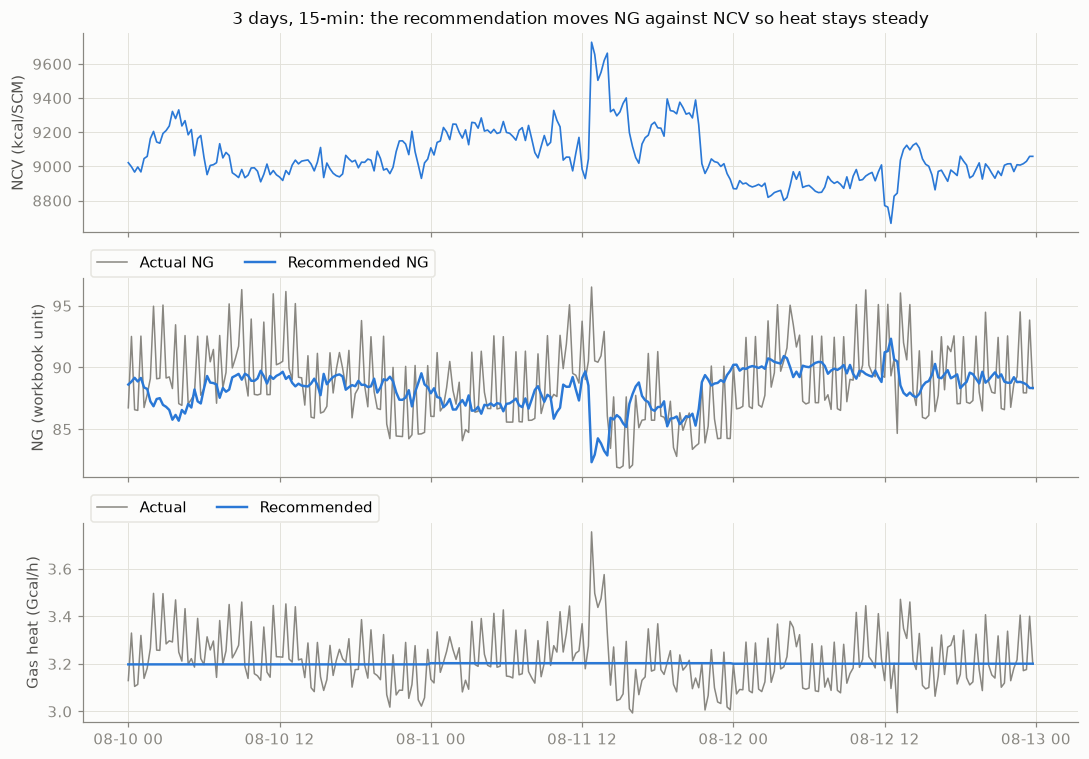

In [9]:
wk = bt_A.loc['2026-08-10':'2026-08-12']
fig, ax = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
ax[0].plot(wk.index, wk.ncv, color=BLUE, lw=1.1); ax[0].set_ylabel('NCV (kcal/SCM)')
ax[1].plot(wk.index, wk.ng_actual, color=MUTED, lw=1.0, label='Actual NG')
ax[1].plot(wk.index, wk.ng_rec, color=BLUE, lw=1.6, label='Recommended NG'); ax[1].set_ylabel('NG (workbook unit)'); ax[1].legend(loc='upper left', ncol=2, frameon=True, facecolor=SURF, edgecolor=GRID, bbox_to_anchor=(0, 1.18))
ax[2].plot(wk.index, wk.heat_actual*4/1e6, color=MUTED, lw=1.0, label='Actual')
ax[2].plot(wk.index, wk.heat_rec*4/1e6, color=BLUE, lw=1.6, label='Recommended'); ax[2].set_ylabel('Gas heat (Gcal/h)'); ax[2].legend(loc='upper left', ncol=2, frameon=True, facecolor=SURF, edgecolor=GRID, bbox_to_anchor=(0, 1.18))
ax[0].set_title('3 days, 15-min: the recommendation moves NG against NCV so heat stays steady')
plt.tight_layout(); plt.show()

The recommended NG moves exactly against NCV, so gas heat input stays flat at the day's target. Actual operation follows NCV only partly and also carries the reversal sawtooth.

## 6. Result per draw band and draw-adjusted (the two target views the client accepted)

In [10]:
base = u[u.in_baseline]
bins, labels = [45, 50, 55, 60, 65], ['45-50', '50-55', '55-60', '60-65']
band_base = base.groupby(pd.cut(base.draw_t, bins, labels=labels, include_lowest=True), observed=True).sfc.mean()
r = dA.copy(); r['band'] = pd.cut(r.draw_t, bins, labels=labels, include_lowest=True)
bt = r.groupby('band', observed=True).agg(days=('sfc', 'size'), actual=('sfc', 'mean'), recommended=('sfc_rec', 'mean'))
bt['baseline_band'] = band_base.reindex(bt.index); bt['target_2pct'] = bt.baseline_band * 0.98
bt['rec_vs_baseline_%'] = 100 * (bt.recommended / bt.baseline_band - 1)
bt['meets_target'] = bt.recommended <= bt.target_2pct
bt.round(1)

,days,actual,recommended,baseline_band,target_2pct,rec_vs_baseline_%,meets_target
band,,,,,,,
45-50,5,1769.9,1761.8,1765.9,1730.6,-0.2,False
50-55,18,1686.7,1680.1,1664.0,1630.8,1.0,False
55-60,33,1588.1,1569.2,1566.7,1535.4,0.2,False
60-65,29,1545.9,1532.0,1521.5,1491.1,0.7,False


In [11]:
mA = smf.ols('E_g ~ draw_t + cullet_pct', base).fit()      # draw-adjusted M&V model (nb03, Model A)
r = r.join(u[['cullet_pct']])
r['E_exp'] = mA.predict(r) * 1e6
r['act_vs_exp_%'] = 100 * (r.energy_kcal / r.E_exp - 1)
r['rec_vs_exp_%'] = 100 * ((r.gas_rec_day + r.elec_kcal) / r.E_exp - 1)
print('Draw-adjusted (energy vs baseline model at the same draw & cullet), Jun-Aug 2026:')
print('  actual       %+.2f%%' % r['act_vs_exp_%'].mean())
print('  recommended  %+.2f%%   (target: -2.00%%)' % r['rec_vs_exp_%'].mean())

Draw-adjusted (energy vs baseline model at the same draw & cullet), Jun-Aug 2026:
  actual       +1.14%
  recommended  +0.25%   (target: -2.00%)


## 7. Air-fuel ratio
The recommended AFR follows NCV, so air per Mcal stays at the target. The air saving comes from moving air per Mcal from the median to the historical P25. nb03 estimates this at about 0.15% energy. It is reported separately and **not** added to the gas back-test above.

In [12]:
print('AFR actual (median %.2f) vs recommended (median %.2f); recommended range %.2f-%.2f; historical P1-P99 %.2f-%.2f' % (
      bt_A.afr_actual.median(), bt_A.afr_rec.median(), bt_A.afr_rec.min(), bt_A.afr_rec.max(), *LIMITS['afr']))

AFR actual (median 12.17) vs recommended (median 11.79); recommended range 10.99-13.11; historical P1-P99 10.99-13.44


## 8. Live use and Sep 2026 validation

In [13]:
# Example: what the operator would see now (inputs typed / read from DB)
example_day = test_days[-1]
print('Daily gas target for', example_day.date(), '= %.1f Gcal' % tgt[example_day])
rec = rc.recommend_gas(tgt[example_day], ncv_now=9200, opt_now=1574.0, opt_target=1574.5,
                       trim_per_degC=TRIM, air_per_mcal=AIR_TARGET, limits=LIMITS)
print('NCV 9200 -> NG %.1f (workbook unit), AFR %.2f, secondary air %.0f' % (rec.ng_setpoint, rec.afr, rec.sec_air))
rec = rc.recommend_gas(tgt[example_day], ncv_now=9600, opt_now=1574.0, opt_target=1574.5,
                       trim_per_degC=TRIM, air_per_mcal=AIR_TARGET, limits=LIMITS)
print('NCV 9600 -> NG %.1f (workbook unit), AFR %.2f, secondary air %.0f' % (rec.ng_setpoint, rec.afr, rec.sec_air))

Daily gas target for 2026-08-31 = 77.0 Gcal
NCV 9200 -> NG 87.3 (workbook unit), AFR 11.57, secondary air 1010
NCV 9600 -> NG 83.6 (workbook unit), AFR 12.07, secondary air 1010


In [14]:
sep = d[(d.index >= '2026-09-01') & d.ncv_ok]
if sep.draw_kg.notna().sum() == 0:
    print('Sep 2026 validation: waiting for the September draw from the client (', len(sep), 'days with NCV ready ).')
else:
    print('Sep 2026 draw available -> rerun this notebook with TEST_START/END set to September.')

Sep 2026 validation: waiting for the September draw from the client ( 28 days with NCV ready ).


## 9. Summary
- **Model:** a daily gas-heat target from a walk-forward 45-day P25 quantile regression (draw, barrier and melter boost). It is spread evenly over the day, trimmed by optical, and divided by the latest NCV every 15 min. AFR follows NCV at the P25 air-per-Mcal.
- **Calibration:** about 25% of test days needed less gas than the target (25% expected), so the target is ambitious but realistic.
- **Safety:** days already at or below the target had normal crown and MB3 temperatures and no extra seeds.
- **Saving (Jun–Aug 2026):** **0.87% SFC** (1.0% of gas) versus actual operation. Scenario A (historical limits) and B (no limits) give the same result, because no recommendation reached the historical NG limits.
- **Against the targets:** draw-adjusted, the furnace moves from **+1.1%** above the baseline model to **+0.25%**. No draw band reaches its −2% target with gas alone. Today's operation is above the baseline because of ageing (nb03). Notebook 05 adds the boost lever and the combined result.